# Quantum Teleportation with Qiskit

In [ ]:
!pip install qiskit
# Reiniciar kernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.8 MB/s eta 0:00:00


In [ ]:
pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.8 MB/s eta 0:00:00


In [ ]:
pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=94232f00fe057ea8d1fa051927bb5563d187ac5bd9fc003539fb57f0c54fb369
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt


# **Teleportación Cuántica**

# **Objetivo:** Transferencia de Información Cuántica

Suponemos que Alice desea enviar su estado cuántico a Bob. El protocolo de teletransportación cuántica permite realizar esta tarea siguiendo cuatro pasos fundamentales:

1. **Preparación del estado:** Alice inicializa su cúbit al estado que desea teletransportar.

2. **Entrelazamiento compartido:** Se genera un par entrelazado (estado de Bell) y se distribuye entre Alice y Bob de modo que cada uno recibe un cúbit.

3. **Cambio de base:** Alice convierte sus dos cúbits de la base de Bell a la base computacional.

4. **Medición:** Alice mide sus dos cúbits y mediante un canal clásico indica a Bob el resultado. Con esta información Bob aplica operaciones a su cúbit para reconstruit el estado deseado.

# 1. Preparación del estado

La teletransportación requiere tres cúbits.
Dos de ellos están corresponden a los cúbits entrelazados que comparten Alice y Bob, el tercero al cúbit con la información que desea teleportación de Alice.
Denotaremos sus estados mediante subíndices:

1. $\vert\cdot\rangle_S,$ El primer cúbit de Alice que preparará en un estado arbitrario.
2. $\vert\cdot\rangle_A,$ El cúbit auxiliar (o "ancilla") de Alice que entrelazará con el cúbit de Bob para comunicarse.
3. $\vert \cdot\rangle_B,$ El cúbit de Bob que recibirá el estado teletransportado.

En conjunto, su estado inicial es:

$$\vert 0\rangle_S \vert 0\rangle_A \vert 0\rangle_B.$$

Lo primero que hace Alice es preparar su primer cúbit en el estado $\vert
\psi\rangle$ que quiera enviar a Bob para que su estado combinado sea:

$$\vert \psi\rangle_S \vert 0\rangle_A \vert 0\rangle_B.$$

Podemos usar la siguiente para realizar el paso de preparación del estado mediante un vector de estado:

In [ ]:
def crear_circuito():
  # Crear registros de cada cúbit con subíndice
  q_S = QuantumRegister(1, name='S')
  q_A = QuantumRegister(1, name='A')
  q_B = QuantumRegister(1, name='B')

  # Crear registros clásicos para almacenar mediciones
  c_S = ClassicalRegister(1, name='cS')
  c_A = ClassicalRegister(1, name='cA')
  c_B = ClassicalRegister(1, name='cB')


  # Crear el circuito con los tres cúbits
  qc = QuantumCircuit(q_S, q_A, q_B, c_S, c_A, c_B)
  return qc, q_S, q_A, q_B, c_S, c_A, c_B

In [ ]:
def inicializar_estado(estado, qc, q_S):
  # Inicializar el estado en el cúbit 'S'
  qc.initialize(estado, q_S[0])

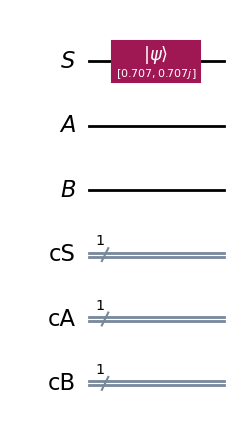

In [ ]:
qc, q_S, q_A, q_B, c_S, c_A, c_B = crear_circuito()
# Estado que se desea mandar
estado_psi = [1/np.sqrt(2), 1j/np.sqrt(2)]

inicializar_estado(estado_psi, qc, q_S)

# Visualizar el circuito
qc.draw('mpl')

# 2. Entrelazamiento compartido

La teletransportación funciona porque utiliza un *estado entrelazado* como recurso compartido entre Alice y Bob.

El entrelazamiento de los cúbits $A$ y $B$ da como resultado el estado combinado:

$$\frac{1}{\sqrt{2}}\left( \vert \psi\rangle_S \vert 0\rangle_A \vert 0\rangle_B + \vert \psi\rangle_S \vert 1\rangle_A \vert 1\rangle_B \right)\tag{1}$$

El subsistema $AB$ se encuentra en un *estado de Bell*. Hay
cuatro estados Bell de dos cúbits máximamente entrelazados que pueden emplearse y que forman la base de Bell:

\begin{align*}
\vert \psi_+\rangle &= \frac{1}{\sqrt{2}} \left( \vert 00\rangle + \vert 11\rangle \right), \\
\vert \psi_-\rangle &= \frac{1}{\sqrt{2}} \left( \vert 00\rangle - \vert 11\rangle \right), \\
\vert \phi_+\rangle &= \frac{1}{\sqrt{2}} \left( \vert 01\rangle + \vert 10\rangle \right), \\
\vert \phi_-\rangle &= \frac{1}{\sqrt{2}} \left( \vert 01\rangle - \vert 10\rangle \right).
\end{align*}

In [ ]:
def entrelazar_par(qc, q_A, q_B):
  qc.h(q_A[0])
  qc.cx(q_A[0], q_B[0])

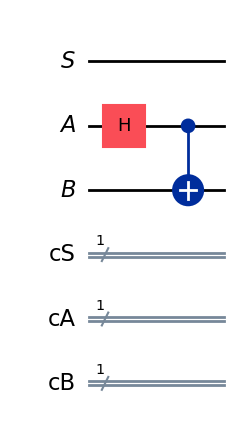

In [ ]:
qc, q_S, q_A, q_B, c_S, c_A, c_B = crear_circuito()
entrelazar_par(qc, q_A, q_B)

# Visualizar el circuito
qc.draw('mpl')

# 3. Cambio de base

El tercer paso del protocolo consiste en aplicar un $CNOT$ y una **Hadamard** a los dos primeros cúbits. Esto corresponde al "cambio de base".

Si el estado inicial $\vert \psi\rangle$ se define como $\alpha\vert 0\rangle + \beta\vert 1\rangle$, donde $\alpha$ y $\beta$ son coeficientes complejos. Desarrollando los términos se tiene:

$$\frac{1}{\sqrt{2}} ( \alpha\vert 000\rangle +
\beta\vert 100\rangle + \alpha \vert 011\rangle +
\beta\vert 111\rangle )$$

Aplicando una $CNOT$ entre los dos cúbits de Alice:

$$\frac{1}{\sqrt{2}} ( \alpha\vert 000\rangle +
\beta\vert 110\rangle + \alpha \vert 011\rangle +
\beta\vert 101\rangle )$$

Y luego un **Hadamard** en su primer cúbit:

$$\frac{1}{2} ( \alpha \vert 000\rangle + \alpha\vert 100\rangle + \beta\vert 010\rangle - \beta\vert 110\rangle + \alpha \vert 011\rangle + \alpha \vert 111 \rangle + \beta\vert 001\rangle - \beta\vert 101 \rangle ).$$

Ahora necesitamos hacer algunos reordenamientos. Agrupamos los términos según la
primeros dos cúbits:

$$\frac{1}{2} \vert 00\rangle(\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 01\rangle (\beta\vert 0\rangle + \alpha\vert 1\rangle) + \frac{1}{2}\vert 10\rangle (\alpha\vert 0\rangle - \beta\vert 1\rangle) + \frac{1}{2}\vert 11\rangle (-\beta\vert 0\rangle + \alpha\vert 1\rangle).\tag{2}$$

In [ ]:
def cambiar_base(qc, q_A, q_S):
  qc.cx(q_S[0], q_A[0])
  qc.h(q_S[0])

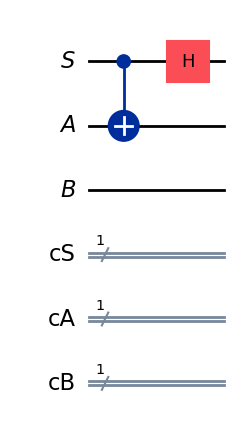

In [ ]:
qc, q_S, q_A, q_B, c_S, c_A, c_B = crear_circuito()
cambiar_base(qc, q_A, q_S)

# Visualizar el circuito
qc.draw('mpl')

# 4. Medición

El último paso del protocolo implica que Alice realice una medición en sus qubits y le indique a Bob que realice algunas operaciones según lo que haya medido.

Si Alice mide sus dos cúbits en la base computacional, tiene la misma probabilidad de obtener cualquiera de los cuatro resultados posibles. Si observa los dos primeros qubits en el estado $\vert 00 \rangle$, sabría inmediatamente que el qubit de Bob estaba en el estado $\alpha \vert 0 \rangle + \beta \vert 1 \rangle$, ¡que es precisamente el estado que intentamos teletransportar!

Si, en cambio, observara los qubits en el estado $\vert 01\rangle$, aún sabría el estado de Bob, pero se desvía ligeramente del estado original. En particular, tenemos:

$$\beta \vert 0 \rangle + \alpha \vert 1 \rangle = X \vert \psi \rangle.$$

Tras obtener estos resultados, Alice podría indicarle a Bob que simplemente aplicara una puerta $X$ a su qubit para recuperar el estado original. De igual manera, si obtuviera $\vert 10\rangle$, le indicaría que aplicara una puerta $Z$.

In [ ]:
def medicion_decodificar(qc, q_S, q_A, q_B, c_S, c_A, c_B):
  qc.measure(q_S[0], c_S[0])
  qc.measure(q_A[0], c_A[0])
  with qc.if_test((c_A[0], 1)):  # Si qubit 1 = 1, aplicar X
    qc.x(q_B[0])
  with qc.if_test((c_S[0], 1)):  # Si qubit 0 = 1, aplicar Z
    qc.z(q_B[0])
  qc.measure(q_B[0], c_B[0])


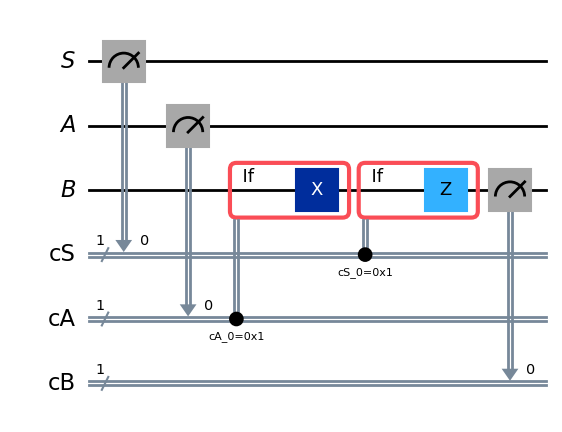

In [ ]:
qc, q_S, q_A, q_B, c_S, c_A, c_B = crear_circuito()
medicion_decodificar(qc, q_S, q_A, q_B, c_S, c_A, c_B)
qc.draw('mpl')


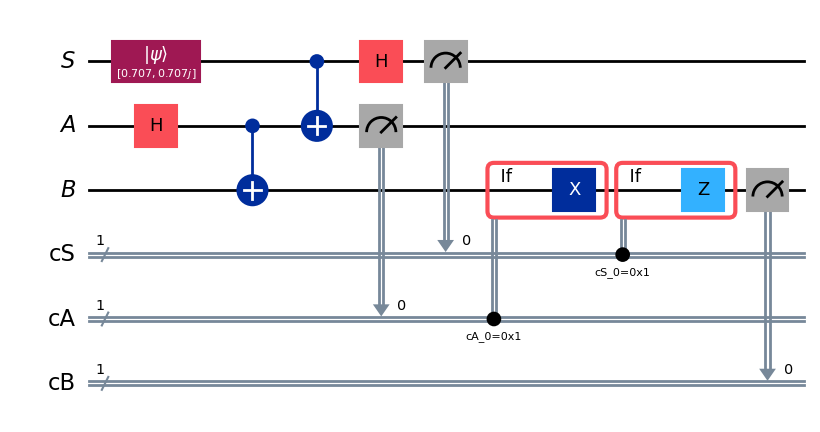

In [ ]:
def circuito_teleportacion(estado):
  qc, q_S, q_A, q_B, c_S, c_A, c_B = crear_circuito()
  inicializar_estado(estado, qc, q_S)
  entrelazar_par(qc, q_A, q_B)
  cambiar_base(qc, q_A, q_S)
  medicion_decodificar(qc, q_S, q_A, q_B, c_S, c_A, c_B)
  return qc

estado_phi = [1/np.sqrt(2), 1j/np.sqrt(2)]
qc = circuito_teleportacion(estado_phi)
qc.draw('mpl')

In [ ]:
# Ejecutar en simulador
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()

counts = result.get_counts()
zeros = 0
unos = 0
for outcome, count in counts.items():
  if(outcome[0] == '0'):
    zeros += count
  else:
    unos += count

cuadrados = [abs(x)**2 for x in estado_phi]
print("Estado inicial P(0)",cuadrados[0],", P(1)",cuadrados[1])
print("Estado Bob: P(0)", zeros/(zeros+unos),", P(1)", unos/(zeros+unos))

Estado inicial P(0) 0.4999999999999999 , P(1) 0.4999999999999999
Estado Bob: P(0) 0.4873046875 , P(1) 0.5126953125


In [ ]:
def normalizar_estado(estado):
    """
    Normalizar un estado cuántico
    Args:
        estado: Estado a teleportar [a0, a1]
    Returns:
        estado/norm: Estado normalizado
    """
    estado = np.array(estado)
    norm = np.linalg.norm(estado)
    if norm == 0:
        raise ValueError("El estado no puede ser el vector cero")
    return estado / norm

def calcular_similitud(estado_entrada, counts):
    """
    Calcular la similitud entre dos estados cuánticos
    Args:
        estado_entrada: Estado a teleportar [a0, a1]
        counts: Resultados de la medición
    Returns:
        errores: Erores en la medición
        prob_resultante: Probabilidades observadas contando el bit de Bob
    """

    # Probabilidades esperadas
    probabilidades_entrada = [abs(x)**2 for x in estado_entrada]
    print(f"Probabilidades esperadas: P(0) = {probabilidades_entrada[0]:.4f}, P(1) = {probabilidades_entrada[1]:.4f}")

    total = sum(counts.values())
    count_0 = sum(count for outcome, count in counts.items() if outcome[0] == '0')  # Último bit
    count_1 = sum(count for outcome, count in counts.items() if outcome[0] == '1')

    prob_resultante = [count_0 / total, count_1 / total]
    print(f"Probabilidades observadas: P(0) = {prob_resultante[0]:.4f}, P(1) = {prob_resultante[1]:.4f}")

    errores = [abs(x - y) for x, y in zip(probabilidades_entrada, prob_resultante)]
    print(f"Diferencias: ΔP(0) = {errores[0]:.4f}, ΔP(1) = {errores[1]:.4f}")

    return errores, prob_resultante

def crear_circuito_teleportacion(estado_entrada):
    """
    Crear circuito de teleportación cuántica
    Args:
        estado_entrada: Estado a teleportar [a0, a1]
    Returns:
        qc: Circuito de teleportación
    """
    # Normalizar el estado
    estado_normalizado = normalizar_estado(estado_entrada)
    qc = circuito_teleportacion(estado_normalizado)

    return qc

def verificacion_probabilidad(estado_entrada, shots=1000):
    """
    Verificación: solo comprobar probabilidades en base computational
    Args:
        estado_entrada: Estado a teleportar [a0, a1]
    Returns:
        qc: Circuito de teleportación
        estado: Estado normalizado
    """

    print(f"📊 Verificación simple - Probabilidades en base Z")
    print("=" * 50)

    estado_original = normalizar_estado(estado_entrada)
    print(f"Estado original: |ψ⟩ = ({estado_original[0]:.4f})|0⟩ + ({estado_original[1]:.4f})|1⟩")

    # Crear circuito con medición final
    qc = crear_circuito_teleportacion(estado_entrada)

    # Simular
    simulator = AerSimulator()
    transpiled = transpile(qc, simulator)
    job = simulator.run(transpiled, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # Contar resultados del qubit 2

    errores, probabilidades_salida = calcular_similitud(estado_entrada, counts)
    # Verificar éxito (tolerancia de 5%)
    success = max(errores) < 0.05

    if success:
        print(f"✅ ¡Probabilidades coinciden! Teleportación exitosa.")
    else:
        print(f"❌ Las probabilidades no coinciden. Puede ser variación estadística.")

    return probabilidades_salida


In [ ]:
"""Demostrar diferentes métodos de verificación"""
# Estados de prueba
estados_prueba = [
    ([1, 0], "Estado |0⟩"),
    ([0, 1], "Estado |1⟩"),
    ([1/np.sqrt(2), 1/np.sqrt(2)], "Estado |+⟩"),
    ([1/np.sqrt(2), -1/np.sqrt(2)], "Estado |-⟩"),
    ([np.sqrt(3)/2, 1/2], "Estado √3/2|0⟩ + 1/2|1⟩"),
    ([0.8, 0.6], "Estado 0.8|0⟩ + 0.6|1⟩"),
]

print("🚀 Demostración de verificación de teleportación cuántica")
print("=" * 70)

for estado, descripcion in estados_prueba:
    print(f"\n{'='*70}")
    print(f"🧪 {descripcion}")
    print(f"{'='*70}")

    # Verificación simple (solo probabilidades)
    verificacion_probabilidad(estado, shots=2000)

🚀 Demostración de verificación de teleportación cuántica

🧪 Estado |0⟩
📊 Verificación simple - Probabilidades en base Z
Estado original: |ψ⟩ = (1.0000)|0⟩ + (0.0000)|1⟩
Probabilidades esperadas: P(0) = 1.0000, P(1) = 0.0000
Probabilidades observadas: P(0) = 1.0000, P(1) = 0.0000
Diferencias: ΔP(0) = 0.0000, ΔP(1) = 0.0000
✅ ¡Probabilidades coinciden! Teleportación exitosa.

🧪 Estado |1⟩
📊 Verificación simple - Probabilidades en base Z
Estado original: |ψ⟩ = (0.0000)|0⟩ + (1.0000)|1⟩
Probabilidades esperadas: P(0) = 0.0000, P(1) = 1.0000
Probabilidades observadas: P(0) = 0.0000, P(1) = 1.0000
Diferencias: ΔP(0) = 0.0000, ΔP(1) = 0.0000
✅ ¡Probabilidades coinciden! Teleportación exitosa.

🧪 Estado |+⟩
📊 Verificación simple - Probabilidades en base Z
Estado original: |ψ⟩ = (0.7071)|0⟩ + (0.7071)|1⟩
Probabilidades esperadas: P(0) = 0.5000, P(1) = 0.5000
Probabilidades observadas: P(0) = 0.5085, P(1) = 0.4915
Diferencias: ΔP(0) = 0.0085, ΔP(1) = 0.0085
✅ ¡Probabilidades coinciden! Teleporta